<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/11_Vision_Transformer_(ViT)_Patch_Projection_and_Multi_Head_Self_Attention_from_Scratch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision einops transformers matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class PatchEmbedding(nn.Module):

    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_channels=3,
                 embed_dim=128):

        super().__init__()

        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.projection = nn.Linear(
            patch_size * patch_size * in_channels,
            embed_dim
        )

    def forward(self, x):

        patches = rearrange(
            x,
            'b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
            p1=self.patch_size,
            p2=self.patch_size
        )

        embeddings = self.projection(patches)

        return embeddings

In [4]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(self,
                 embed_dim=128,
                 num_heads=8):

        super().__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)

        self.fc = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):

        B, N, C = x.shape

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(3, dim=-1)

        q = rearrange(q, 'b n (h d) -> b h n d', h=self.num_heads)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.num_heads)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.num_heads)

        energy = torch.einsum(
            'bhqd,bhkd->bhqk',
            q,
            k
        )

        attention = torch.softmax(
            energy / (self.head_dim ** 0.5),
            dim=-1
        )

        out = torch.einsum(
            'bhqk,bhkd->bhqd',
            attention,
            v
        )

        out = rearrange(out, 'b h n d -> b n (h d)')

        out = self.fc(out)

        return out, attention

In [5]:
class MLP(nn.Module):

    def __init__(self,
                 embed_dim=128,
                 hidden_dim=256):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(embed_dim, hidden_dim),

            nn.GELU(),

            nn.Linear(hidden_dim, embed_dim)

        )

    def forward(self, x):

        return self.net(x)

In [6]:
class TransformerEncoder(nn.Module):

    def __init__(self,
                 embed_dim=128,
                 num_heads=8):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = MultiHeadSelfAttention(
            embed_dim,
            num_heads
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = MLP(embed_dim)

    def forward(self, x):

        attn_out, attention = self.attention(self.norm1(x))

        x = x + attn_out

        x = x + self.mlp(self.norm2(x))

        return x, attention

In [7]:
class VisionTransformer(nn.Module):

    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_channels=3,
                 num_classes=10,
                 embed_dim=128,
                 num_heads=8):

        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size,
            patch_size,
            in_channels,
            embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(
            torch.randn(1,1,embed_dim)
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(
                1,
                num_patches+1,
                embed_dim
            )
        )

        self.encoder = TransformerEncoder(
            embed_dim,
            num_heads
        )

        self.head = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self, x):

        x = self.patch_embed(x)

        B = x.shape[0]

        cls = self.cls_token.expand(B,-1,-1)

        x = torch.cat((cls,x),dim=1)

        x = x + self.pos_embedding

        x, attention = self.encoder(x)

        logits = self.head(x[:,0])

        return logits, attention

In [8]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

100%|██████████| 170M/170M [48:20<00:00, 58.8kB/s]


In [9]:
model = VisionTransformer().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = nn.CrossEntropyLoss()

In [10]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs, _ = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}"
    )

Epoch 1 Loss: 1.8041
Epoch 2 Loss: 1.5528
Epoch 3 Loss: 1.4498
Epoch 4 Loss: 1.3845
Epoch 5 Loss: 1.3306


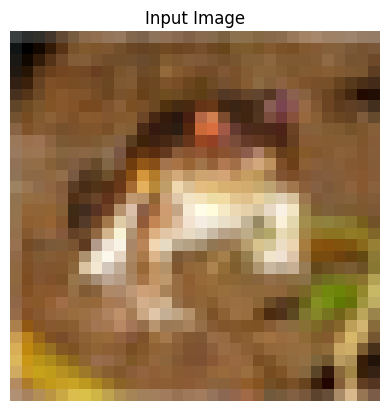

Actual Label: 6
Predicted: 6


In [11]:
image, label = dataset[0]

plt.imshow(image.permute(1,2,0))
plt.title("Input Image")
plt.axis("off")
plt.show()

x = image.unsqueeze(0).to(device)

prediction, attention = model(x)

predicted = prediction.argmax(dim=1).item()

print("Actual Label:", label)
print("Predicted:", predicted)

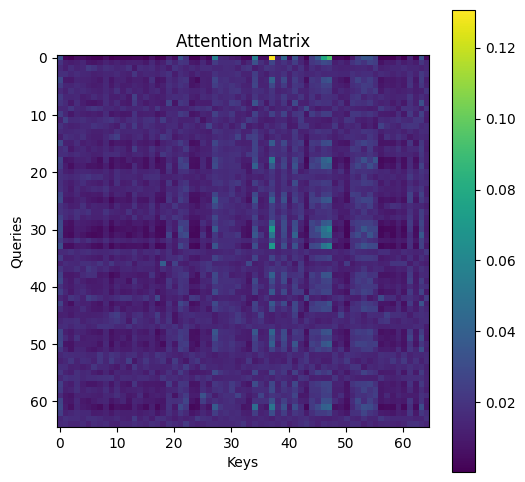

In [12]:
attention = attention.detach().cpu()

attn = attention[0,0]

plt.figure(figsize=(6,6))

plt.imshow(attn, cmap="viridis")

plt.colorbar()

plt.title("Attention Matrix")

plt.xlabel("Keys")

plt.ylabel("Queries")

plt.show()